# Continuing on Data preprocessing Steps 

### What we make in previous workshop

In [2]:
import pandas as pd

df=pd.read_csv("CSVdata/Titanic.csv")
df.drop(['PassengerId','Name','Ticket'],axis=1,inplace=True)

cols=["Survived","Pclass","Sex","SibSp","Parch","Embarked"]
df[cols]=df[cols].astype("category")
nunique=df.nunique()
dtype=df.dtypes
nunique=df.nunique()
pd.DataFrame({"data type" : dtype, "num unique values":nunique}).T
df.isnull().sum()
df.info()
null=df.isnull().sum()
# if ratio 35% or less we fill data from historical data 70% that i have
        # if numerical we use mean or median if it categorical use mode 
        # if data has outliers use median if not use mean 
# else 
# drop nullvalues or if i need it -> search for relationship between this column and another one using combination 
ratio=(null/df.shape[0])*100
df=df.dropna(subset=['Embarked'])
df=df.drop(['Cabin'],axis=1)
median=df['Age'].median()
df['Age']=df['Age'].fillna(median)

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   Survived  891 non-null    category
 1   Pclass    891 non-null    category
 2   Sex       891 non-null    category
 3   Age       714 non-null    float64 
 4   SibSp     891 non-null    category
 5   Parch     891 non-null    category
 6   Fare      891 non-null    float64 
 7   Cabin     204 non-null    str     
 8   Embarked  889 non-null    category
dtypes: category(6), float64(2), str(1)
memory usage: 26.7 KB


### 8-Check Outleirs

<details>
<summary><strong>Popular Outlier Detection Algorithms</strong></summary>

### 1. IQR (Interquartile Range)

Uses **Q1 and Q3** to detect values far from the middle 50%.

```text
IQR = Q3 - Q1

Lower Bound = Q1 - 1.5 × IQR
Upper Bound = Q3 + 1.5 × IQR
```

* Outside the bounds → **Outlier**
* Good for data that is **not normally distributed**
* Not affected much by extreme values

---

### 2. Z-Score

Measures how far a value is from the **mean**.

```text
Z = (x - mean) / standard deviation
```

Usually:

```text
|Z| > 3 → Outlier
```

* Good for **normally distributed data**
* Sensitive to extreme values

---

### 3. MAD (Median Absolute Deviation)

Measures how far values are from the **median**.

```text
MAD = median(|x - median|)
```

* Robust against outliers
* Good for **skewed data**
* More robust than Z-Score

---

### Quick Comparison

| Method      | Best For                  | Sensitive to Outliers |
| ----------- | ------------------------- | --------------------- |
| **IQR**     | General / skewed data     | No                    |
| **Z-Score** | Normal distribution       | Yes                   |
| **MAD**     | Skewed / robust detection | No                    |

</details>


In [3]:
col_num=df.select_dtypes("number").columns
col_num

Index(['Age', 'Fare'], dtype='str')

In [4]:
for col in col_num:
    Q1=df[col].quantile(0.25)
    Q3=df[col].quantile(0.75)
    IQR=Q3-Q1
    lower_fence=Q1-1.5*IQR
    upper_fence=Q3+1.5*IQR
    # print(col,lower_fence,upper_fence)
    lower_outliers=df[df[col]<lower_fence][col].values
    upper_outliers=df[df[col]>upper_fence][col].values
    print(lower_outliers)
    print(upper_outliers)
    

[2.   2.   0.83 2.   1.   1.   1.   2.   2.   0.92 2.   1.   1.   0.75
 2.   2.   2.   0.75 0.67 1.   0.42 2.   1.   0.83]
[58.  55.  66.  65.  59.  71.  70.5 55.5 61.  56.  58.  59.  62.  58.
 63.  65.  61.  60.  64.  65.  56.  63.  58.  55.  71.  64.  62.  62.
 60.  61.  57.  80.  56.  58.  70.  60.  60.  70.  57.  74.  56. ]
[]
[ 71.2833 263.     146.5208  82.1708  76.7292  83.475   73.5    263.
  77.2875 247.5208  73.5     77.2875  79.2     66.6     69.55    69.55
 146.5208  69.55   113.275   76.2917  90.      83.475   90.      79.2
  86.5    512.3292  79.65   153.4625 135.6333  77.9583  78.85    91.0792
 151.55   247.5208 151.55   110.8833 108.9     83.1583 262.375  164.8667
 134.5     69.55   135.6333 153.4625 133.65    66.6    134.5    263.
  75.25    69.3    135.6333  82.1708 211.5    227.525   73.5    120.
 113.275   90.     120.     263.      81.8583  89.1042  91.0792  90.
  78.2667 151.55    86.5    108.9     93.5    221.7792 106.425   71.
 106.425  110.8833 227.525   79.65 

In [5]:
df.describe()

,Age,Fare
count,889.000000,889.000000
mean,29.315152,32.096681
std,12.984932,49.697504
min,0.420000,0.000000
25%,22.000000,7.895800
50%,28.000000,14.454200
75%,35.000000,31.000000
max,80.000000,512.329200


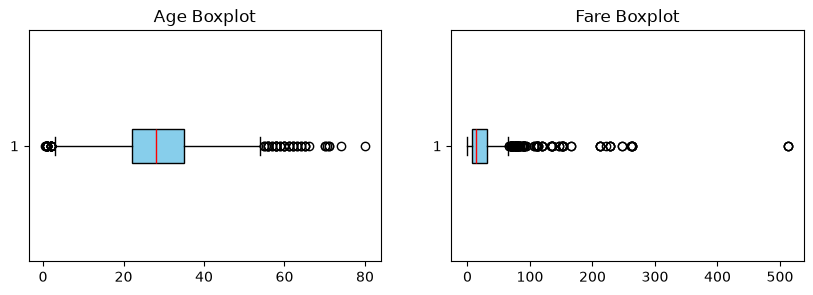

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,3))

for i , col in enumerate(col_num):
    plt.subplot(1,2,i+1)
    plt.boxplot(df[col],orientation='horizontal',
                                    patch_artist=True,
                                    boxprops=dict(facecolor="skyblue"),
                                    medianprops=dict(color="red"),
                                    whiskerprops=dict(color="black"),
                                    capprops=dict(color="black"))
    plt.title(f"{col} Boxplot")
    

plt.show()


## 9- Handle outliers

In [7]:
#method 1 :  replacement of outliers with outlier fence value (Replacment) (Cliping)

for col in col_num:
    Q1=df[col].quantile(0.25)
    Q3=df[col].quantile(0.75)
    IQR=Q3-Q1
    lower_fence=Q1-1.5*IQR
    upper_fence=Q3+1.5*IQR
    lower_outliers=df[df[col]<lower_fence][col].values
    upper_outliers=df[df[col]>upper_fence][col].values

    # SOLUTION 
    df[col]=df[col].replace(lower_outliers,lower_fence)
    df[col]=df[col].replace(upper_outliers,upper_fence)
    

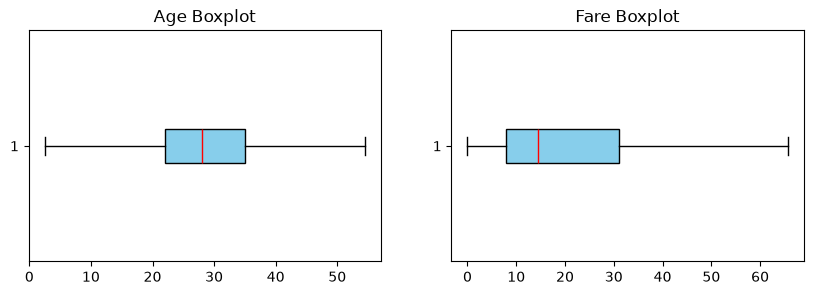

In [8]:


plt.figure(figsize=(10,3))

for i , col in enumerate(col_num):
    plt.subplot(1,2,i+1)
    plt.boxplot(df[col],orientation='horizontal',
                    patch_artist=True,
                    boxprops=dict(facecolor="skyblue"),
                    medianprops=dict(color="red"),
                    whiskerprops=dict(color="black"),
                    capprops=dict(color="black"))
    plt.title(f"{col} Boxplot")
    

plt.show()

In [9]:
# built in function make replacement method (cliping)
for col in col_num:
    Q1=df[col].quantile(0.25)
    Q3=df[col].quantile(0.75)
    IQR=Q3-Q1
    lower_fence=Q1-1.5*IQR
    upper_fence=Q3+1.5*IQR
    lower_outliers=df[df[col]<lower_fence][col].values
    upper_outliers=df[df[col]>upper_fence][col].values

    # SOLUTION 
    df[col].clip(lower_fence,upper_fence)

In [10]:
# method 2 : Remove outliers

In [11]:
# method 3:  use mean and median of data

## 9-Check Duplicates

In [12]:
df.duplicated().sum()


np.int64(129)

## 10-Handle Duplicates

In [ ]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

In [14]:
def remove_duplicate(df,subset_cols=None,keep_startegy='first'):
    return (df.drop_duplicates(subset=subset_cols,keep=keep_startegy).reset_index(drop=True))



# GRAPHS

### Numerical Data

In [15]:
num_col=df.select_dtypes('number').columns
num_col

Index(['Age', 'Fare'], dtype='str')

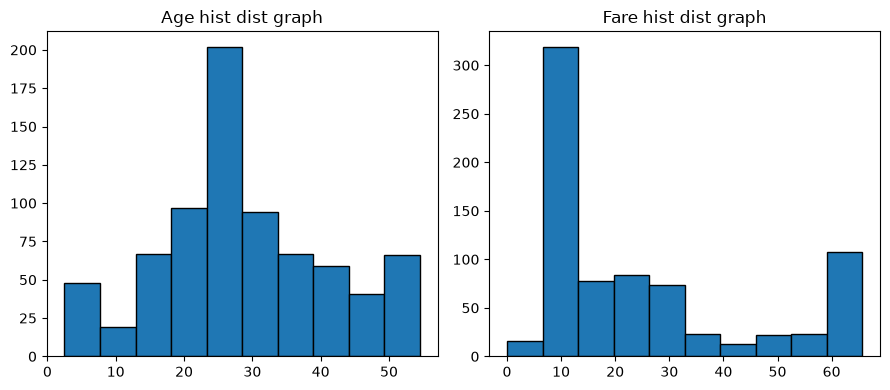

In [16]:
plt.figure(figsize=(9,4))
for i , col in enumerate(num_col):
    plt.subplot(1,2,i+1)
    plt.hist(df[col],edgecolor='black')
    plt.title(f"{col} hist dist graph")
    plt.tight_layout()

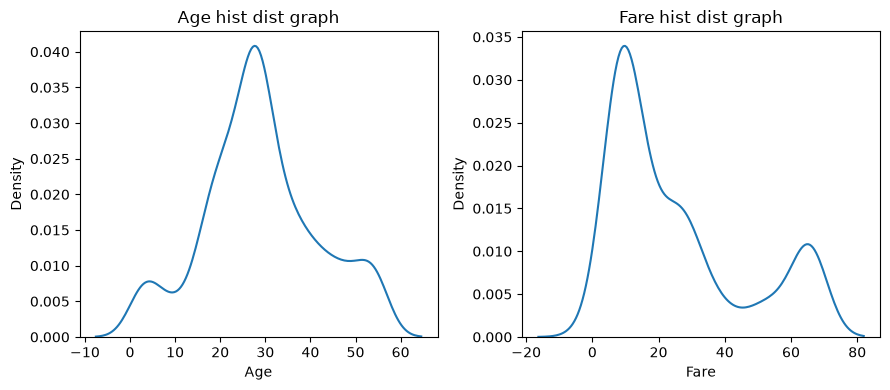

In [17]:
plt.figure(figsize=(9,4))
for i , col in enumerate(num_col):
    plt.subplot(1,2,i+1)
    # normalize and continous 
    sns.kdeplot(df[col])
    plt.title(f"{col} hist dist graph")
    plt.tight_layout()

### Categorical Data

In [18]:
cat_col=df.select_dtypes('category').columns
cat_col

Index(['Survived', 'Pclass', 'Sex', 'SibSp', 'Parch', 'Embarked'], dtype='str')

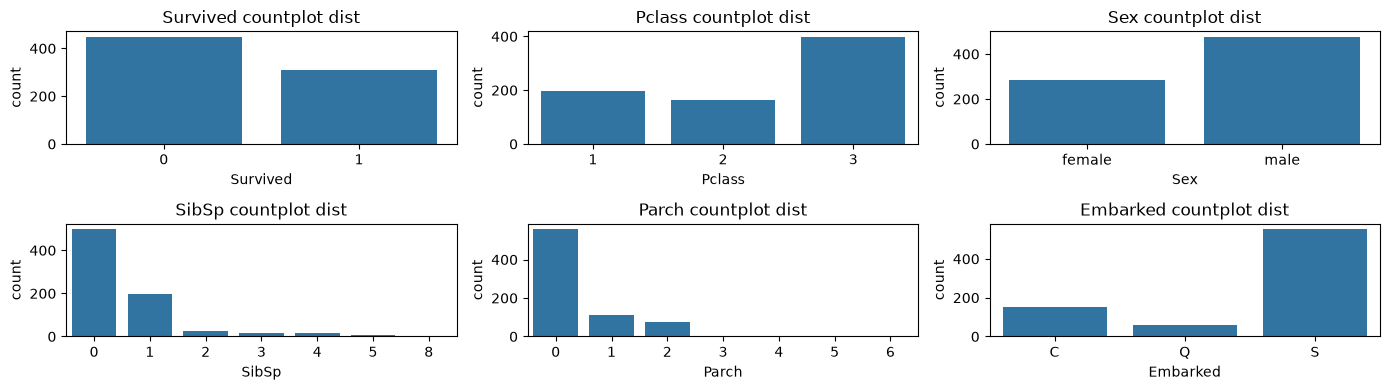

In [19]:
plt.figure(figsize=(14,4))

for i , col in enumerate(cat_col):
    plt.subplot(2,3,i+1)
    sns.countplot(x=col,data=df)
    plt.title(f"{col} countplot dist")
    plt.tight_layout()

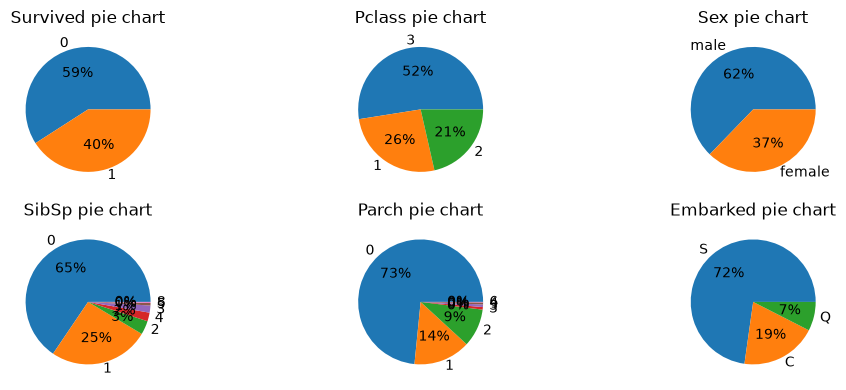

In [20]:
# pie plot suit to 2 to 3 categories
plt.figure(figsize=(14,4))

for i , col in enumerate(cat_col):
    plt.subplot(2,3,i+1)
    unique=df[col].value_counts()
    count=(unique.values)
    catgories=unique.index

    plt.pie(count,labels=catgories,autopct='%1.1d%%')
    plt.title(f"{col} pie chart")
    plt.tight_layout()

### Relationship between columns

<Axes: >

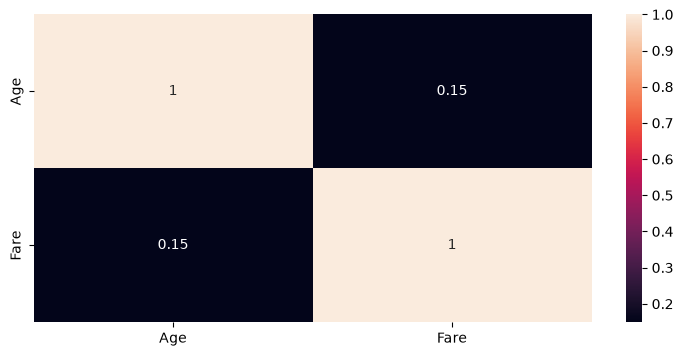

In [34]:
plt.figure(figsize=(9,4))

# plt.subplot(1,4,1)
# plt.scatter(df['Age'],df['Fare'])

# plt.subplot(1,4,2)
# plt.plot(df['Age'],df['Fare'])

# # give me collection of grapths for your numerical columns in dataframe
# # each row on it show distribution of each column and it's scatter plot
# sns.pairplot(df)

sns.heatmap(df[['Age','Fare']].corr(),annot=True)

# plt.xlabel("Age")
# plt.ylabel("Fare")



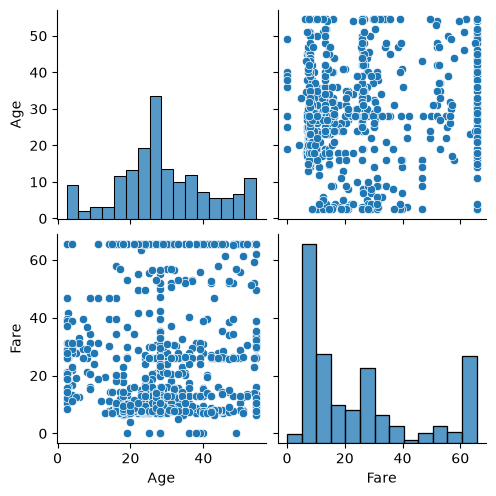

In [22]:
sns.pairplot(df)